<h1 align="center">Superstore Sales Analytics</h1>
<h1 align="center">Created by: Ashraf</h1>

## Business Questions 

- Which markets and regions generate the most sales and profit?
- Which product categories or sub-categories perform best?
- How do discounts impact profitability?
- What shipping modes and priorities are most commonly used?
- Which customer segments contribute the most revenue?

## Data collection

<p align="center">
    Pandas | Matplotlib.pyplot | Seaborn | Plotly.Express
</p>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# loat SuperStore Sales Dataset
df = pd.read_csv('SuperStoreOrders/SuperStoreOrdersDataset.csv')

In [3]:
# diplay all columns
pd.options.display.max_columns = None

In [4]:
# display first five rows
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [5]:
# display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [6]:
# show all column names in the dataset
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [7]:
# display the shape of the dataset (rows, columns)
df.shape

(51290, 21)

In [8]:
# show the total number of elements in the dataset
df.size

1077090

In [9]:
# display statistical summary of numerical columns
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


# Data Cleaning

In [10]:
# check duplicated into dataset
df.duplicated().sum()

np.int64(0)

In [11]:
# check missing values
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [12]:
# Display the first row of the dataset
df.head(1)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.14,35.46,Medium,2011


In [13]:
# Convert columns to datetime format
df['order_date'] = pd.to_datetime(df['order_date'],dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'],dayfirst=True)

In [14]:
# Check the data types to confirm the change
df[['order_date','ship_date']].dtypes

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object

In [15]:
# rename 'shipping_cost' to 'cost'
df.rename(columns={'shipping_cost':'cost'},inplace=True)

In [16]:
# convert Sales column to Numeric (float)
df['sales'] = pd.to_numeric(df['sales'],errors='coerce')

In [17]:
# check the data types to confirm the change
df.dtypes

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
cost                     float64
order_priority            object
year                       int64
dtype: object

# Exploratory Data Analysis (EDA)

In [18]:
# Display 3 random rows from the dataset
df.sample(3)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,cost,order_priority,year
35014,IN-2014-73048,2014-02-14,2014-02-16,Second Class,Ann Chong,Corporate,Jiangsu,China,APAC,North Asia,FUR-FU-10000541,Furniture,Furnishings,"Advantus Frame, Duo Pack",222.0,2,0.0,57.78,17.97,Medium,2014
22477,ES-2013-2161351,2013-04-16,2013-04-23,Standard Class,Guy Phonely,Corporate,Nord-Pas-de-Calais,France,EU,Central,OFF-LA-10004148,Office Supplies,Labels,"Smead File Folder Labels, 5000 Label Set",28.0,3,0.0,12.78,2.09,Medium,2013
11960,IN-2012-48240,2012-05-25,2012-05-28,Second Class,Guy Phonely,Corporate,Delhi,India,APAC,Central Asia,OFF-EN-10002556,Office Supplies,Envelopes,"Ames Business Envelopes, Recycled",68.0,4,0.0,29.28,5.16,Critical,2012


In [19]:
# Check unique values
df['market'].unique()

array(['Africa', 'APAC', 'EMEA', 'EU', 'Canada', 'LATAM', 'US'],
      dtype=object)

In [20]:
# Check unique values
df['region'].unique()

array(['Africa', 'Oceania', 'EMEA', 'North', 'Canada', 'Southeast Asia',
       'Central', 'South', 'Caribbean', 'North Asia', 'East', 'West',
       'Central Asia'], dtype=object)

### Question 1
- Which markets and regions generate the most sales and profit?

In [21]:
df.groupby(['market','region'])['sales'].sum().sort_values(ascending=False).reset_index().groupby('market').first().sort_values(by='sales',ascending=False).reset_index()

,market,region,sales
0,EU,Central,1063946.0
1,APAC,Oceania,625382.0
2,EMEA,EMEA,575562.0
3,Africa,Africa,538115.0
4,LATAM,South,453674.0
5,US,West,424173.0
6,Canada,Canada,50314.0


- the EU market (Central region) has the highest sales, it made more than 1 millions in sales.
- the APAC market (Oceania region) is in second place with about 625k in sales.
- the Canada market has lowest sales in this list about 50k.

In [22]:
df.groupby(['market','region'])['profit'].sum().sort_values(ascending=False).reset_index().groupby('market').first().sort_values(by='profit',ascending=False).reset_index()

,market,region,profit
0,EU,Central,215534.06850
1,APAC,North Asia,165578.42100
2,US,West,108418.44890
3,LATAM,North,102818.09752
4,Africa,Africa,88871.63100
5,EMEA,EMEA,43897.97100
6,Canada,Canada,17817.39000


- the EU market (Central region) also makes the highest profit (about 215k), this means it's our best market.
- the APAC market (North Asia region) is in second place for profit but the best region for profit is North Asia not Oceania.
- the Canada markt (Canada region) makes the lowest profit (about 17k)

### Question 2
- Which product categories or sub-categories perform best?

In [23]:
df.sample(2)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,cost,order_priority,year
28529,ES-2013-3851418,2013-09-14,2013-09-18,Standard Class,Lela Donovan,Corporate,England,United Kingdom,EU,North,OFF-AP-10000172,Office Supplies,Appliances,"Cuisinart Toaster, Silver",379.0,7,0.0,87.15,18.16,Medium,2013
50393,ES-2014-1137361,2014-12-18,2014-12-25,Standard Class,Ben Peterman,Corporate,Scotland,United Kingdom,EU,North,OFF-EN-10001993,Office Supplies,Envelopes,"GlobeWeis Manila Envelope, Set of 50",55.0,2,0.0,18.06,4.17,Medium,2014


In [24]:
df['category'].unique()

array(['Office Supplies', 'Furniture', 'Technology'], dtype=object)

In [25]:
df.groupby(['category','sub_category'])['product_id'].count().sort_values(ascending=False).reset_index().groupby('category').first().sort_values(by='product_id',ascending=False).reset_index()

,category,sub_category,product_id
0,Office Supplies,Binders,6152
1,Furniture,Chairs,3434
2,Technology,Phones,3357


- the Office Supplies category (Binders) is highest perform.
- the Technology category (Phones) is lowest perform.

### Question 3
- How do discounts impact profitability?

In [26]:
df.sample(2)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,cost,order_priority,year
41153,ES-2014-3388021,2014-07-16,2014-07-17,First Class,Daniel Raglin,Home Office,Veneto,Italy,EU,South,OFF-BI-10002354,Office Supplies,Binders,"Acco Binder, Clear",44.0,3,0.0,14.4,5.39,Medium,2014
19017,HU-2012-4000,2012-12-08,2012-12-11,Second Class,Chad Cunningham,Home Office,Budapest,Hungary,EMEA,EMEA,OFF-STI-10003510,Office Supplies,Supplies,"Stiletto Trimmer, Easy Grip",44.0,1,0.0,10.2,0.24,Medium,2012


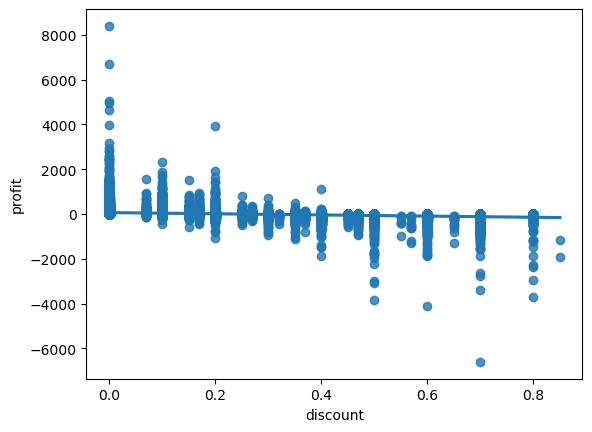

In [28]:
sns.regplot(x=df['discount'], y=df['profit'])
plt.show()

- Large discounts can lead to lower profits.
- The relationship isn't strong, but there's a downward trend.

### Question 4
- What shipping modes and priorities are most commonly used?

In [29]:
df.sample(2)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,cost,order_priority,year
42551,ID-2014-82309,2014-08-16,2014-08-21,Standard Class,Fred Wasserman,Corporate,Auckland,New Zealand,APAC,Oceania,OFF-ST-10003293,Office Supplies,Storage,"Smead File Cart, Single Width",154.0,2,0.4,5.136,12.07,Medium,2014
33084,ID-2013-65061,2013-12-18,2013-12-20,Second Class,Tracy Blumstein,Consumer,Punjab,Pakistan,APAC,Central Asia,OFF-BI-10003012,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Economy",7.0,3,0.5,-1.035,0.55,High,2013


In [30]:
df.groupby(['ship_mode','order_priority'])['order_id'].count().sort_values(ascending=False).idxmax()

('Standard Class', 'Medium')

- Standard Class is the most commonly used shipping mode.
- Most orders also have Medium priority.

### Question 5
- Which customer segments contribute the most revenue?

In [31]:
df.sample(2)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,cost,order_priority,year
16918,CA-2012-109190,2012-10-23,2012-10-28,Standard Class,Craig Carroll,Consumer,Texas,United States,US,Central,OFF-PA-10000069,Office Supplies,Paper,"TOPS 4 x 6 Fluorescent Color Memo Sheets, 500 ...",61.0,8,0.2,20.4984,3.03,Medium,2012
12820,GB-2012-6200,2012-06-19,2012-06-23,Standard Class,Joseph Airdo,Consumer,Estuaire,Gabon,Africa,Africa,OFF-AVE-10002311,Office Supplies,Binders,"Avery Binder Covers, Durable",75.0,6,0.0,9.7200,8.94,High,2012


In [32]:
df.groupby('segment')['sales'].sum().sort_values(ascending=False).idxmax()

'Consumer'

- the consumer segment is the customer segment that contributes the most to revenue.
- this means most sales come from individual customers.

# Data Visualization

In [33]:
df.sample(2)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,cost,order_priority,year
45857,ID-2014-24538,2014-10-10,2014-10-12,Second Class,Pamela Coakley,Corporate,Calabarzon,Philippines,APAC,Southeast Asia,FUR-BO-10002738,Furniture,Bookcases,"Sauder Corner Shelving, Mobile",195.0,2,0.35,-95.934,31.73,High,2014
25136,MX-2013-111213,2013-06-25,2013-06-27,Second Class,Ann Blume,Corporate,Guatemala,Guatemala,LATAM,Central,OFF-ST-10003729,Office Supplies,Storage,"Tenex Box, Industrial",79.0,7,0.00,13.440,6.56,High,2013


In [34]:
sales_years = df.groupby('year')['sales'].sum()
sales_years

year
2011    1378151.0
2012    1681499.0
2013    2107021.0
2014    2668457.0
Name: sales, dtype: float64

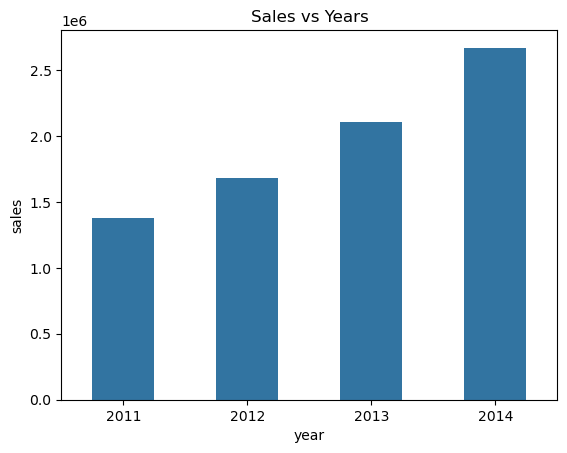

In [35]:
sns.barplot(x=sales_years.index,y=sales_years.values,width=.5)
plt.title('Sales vs Years')
plt.ylabel('sales')
plt.show()

- the year 2014 was the highest revenue
- the year 2011 was the lowest revenue

In [36]:
df['category'].unique()

array(['Office Supplies', 'Furniture', 'Technology'], dtype=object)

In [37]:
category_revenue = df.groupby('category')['sales'].sum()
category_revenue

category
Furniture          2406605.0
Office Supplies    2790258.0
Technology         2638265.0
Name: sales, dtype: float64

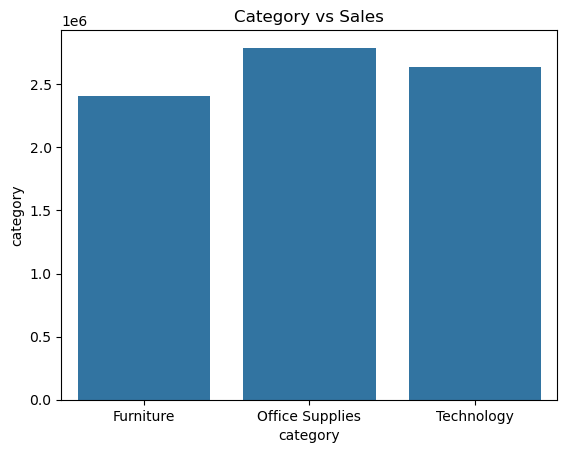

In [38]:
sns.barplot(x=category_revenue.index, y=category_revenue.values)
plt.title('Category vs Sales')
plt.ylabel('category')
plt.show()

- office supplies product has the highest revenue compared to other category

In [39]:
df['ship_mode'].unique()

array(['Standard Class', 'Second Class', 'Same Day', 'First Class'],
      dtype=object)

In [40]:
ship_mode = df.groupby('ship_mode')['order_id'].count()
ship_mode

ship_mode
First Class        7505
Same Day           2701
Second Class      10309
Standard Class    30775
Name: order_id, dtype: int64

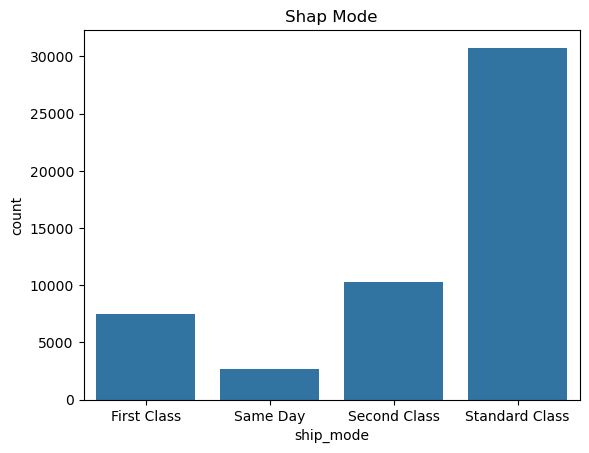

In [41]:
sns.barplot(x=ship_mode.index, y=ship_mode.values)
plt.title('Shap Mode')
plt.ylabel('count')
plt.show()

- standard class is the most commonly used shipping mode

In [42]:
market_order = df.groupby('market')['sales'].sum().sort_values(ascending=False)
market_order

market
APAC      2000746.0
EU        1803099.0
LATAM     1563126.0
US        1304166.0
EMEA       575562.0
Africa     538115.0
Canada      50314.0
Name: sales, dtype: float64

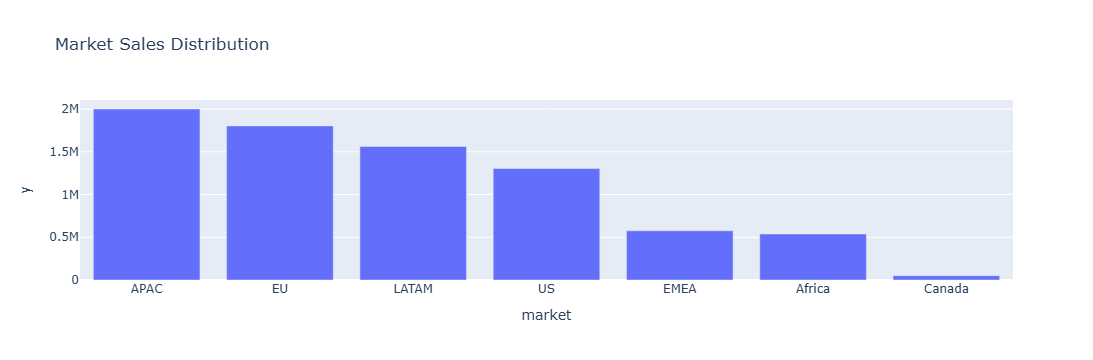

In [43]:
px.bar(data_frame=market_order, x=market_order.index, y=market_order.values,title='Market Sales Distribution')

- APAC market has the highest sales among all markets.
- EU and LATAM also show strong sales performance.
- Canada has the lowest sales compared to other markets.

# Insight

1. The EU market (Central region) generated the highest sales with more than 1 million in revenue.  
   The APAC market (Oceania region) comes in second place with about 625k in sales.  
   Canada has the lowest sales in this dataset with around 50k.

2. The EU market (Central region) also generated the highest profit (about 215k).  
   This makes it the best performing market.  
   The APAC market (North Asia region) is the second highest in profit.

3. In product categories, Office Supplies performs the best, especially the Binders sub-category.  
   The Technology category (Phones) shows the lowest performance in this analysis.

4. Large discounts can lead to lower profits.  
   The relationship is not very strong, but there is a downward trend.

5. Standard Class is the most commonly used shipping mode.  
   Most orders also have Medium priority.

6. The Consumer segment contributes the most revenue.  
   This means most sales come from individual customers.

7. Sales increased over time.  
   The year 2014 had the highest revenue, while 2011 had the lowest.

8. Office Supplies products generate the highest revenue compared to other categories.

9. The APAC market also shows very strong sales performance.  
   EU and LATAM markets also perform well, while Canada has the lowest sales.

# Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Plotly Express
- Jupyter Notebook